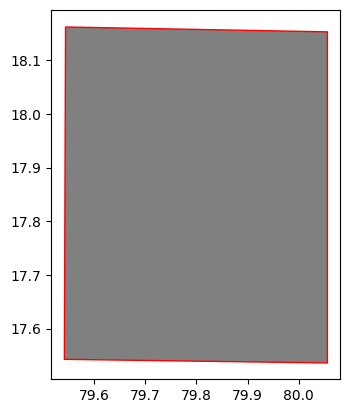

Original bounds: [79.54032281 17.53684316 80.05539897 18.16310315]


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the KML
gdf = gpd.read_file('/content/TG_bounding_box.kml', driver='KML')

# Plot to see the full AOI
gdf.plot(edgecolor='red', facecolor='grey')
plt.show()

# Get bounds (minx, miny, maxx, maxy)
bounds = gdf.total_bounds
print("Original bounds:", bounds)

# Manually define smaller AOI — change numbers as needed
small_aoi_bounds = [80.0, 17.0, 80.2, 17.1]  # lon_min, lat_min, lon_max, lat_max

In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='38552541158')

# Define smaller bounding box in EE
small_aoi = ee.Geometry.BBox(*small_aoi_bounds)
display(small_aoi)

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              80.0,
              17.1
            ],
            [
              80.0,
              17.0
            ],
            [
              80.2,
              17.0
            ],
            [
              80.2,
              17.1
            ]
          ]
        ]
      },
      "geodesic": {
        "constantValue": false
      }
    }
  }
})

In [3]:
s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(small_aoi) \
    .filterDate('2024-07-01', '2024-08-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .select(['VV', 'VH', 'angle']) \
    .sort('system:time_start')

In [4]:
# Select the first image in the collection
first_image = s1.first()

# Define visualization parameters for False Color (VV, VH, Angle)
# Adjusted min/max based on data ranges
vis_params = {
    'min': -25,
    'max': 0,
    'bands': ['VV', 'VH', 'angle']
}

# Task
Visualize the `first_image` Earth Engine image on an interactive map using the `geemap` library, displaying the 'VV', 'VH', and 'angle' bands with the specified visualization parameters.

## Install geemap

### Subtask:
Install the `geemap` library in the Colab environment.


**Reasoning**:
The subtask is to install the `geemap` library. This can be done using the `!pip install` command in a code cell.



In [5]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00


## Import geemap

### Subtask:
Import the `geemap` library.


**Reasoning**:
Import the geemap library as requested in the subtask.



In [20]:
import geemap

## Create a geemap map

### Subtask:
Create a `geemap` interactive map object, potentially centered on the area of interest.


**Reasoning**:
Create a geemap interactive map object and center it on the small_aoi.



In [7]:
Map = geemap.Map()
Map.centerObject(small_aoi, zoom=10)
display(Map)

Map(center=[17.05000369460201, 80.09999999999941], controls=(WidgetControl(options=['position', 'transparent_b…

## Add earth engine layer to geemap

### Subtask:
Add the selected Earth Engine image (`first_image`) to the `geemap` map as a layer using the visualization parameters (`vis_params`).


**Reasoning**:
Add the Earth Engine image `first_image` to the `geemap` map using the defined visualization parameters `vis_params`.



In [21]:
Map.addLayer(first_image, vis_params, 'Sentinel-1 False Color')

## Display the geemap map

### Subtask:
Show the interactive `geemap` map.


**Reasoning**:
Display the geemap Map object to show the interactive map with the added layer.



In [9]:
display(Map)

Map(center=[17.05000369460201, 80.09999999999941], controls=(WidgetControl(options=['position', 'transparent_b…

## Summary:

### Data Analysis Key Findings

*   The `geemap` library was successfully installed and imported.
*   An interactive `geemap` map was created and centered on the specified area of interest (`small_aoi`) with a zoom level of 10.
*   The `first_image` Earth Engine image was added to the map as a layer named 'Sentinel-1 False Color', using the provided visualization parameters for the 'VV', 'VH', and 'angle' bands.
*   The interactive map containing the added layer was successfully displayed.

### Insights or Next Steps

*   The visualized Sentinel-1 false color composite highlights different surface features based on the backscatter values of the VV and VH polarizations and the local incidence angle.
*   Further analysis could involve examining the characteristics of different features within the area of interest based on their appearance in this false color composite.


In [22]:
# Get the minimum and maximum values for each band in the small_aoi
stats = first_image.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=small_aoi,
    scale=10, # Use an appropriate scale for Sentinel-1 data (e.g., 10 meters)
    maxPixels=1e9
)

# Print the minimum and maximum values
print("Band value ranges within small_aoi:")
print("VV:", stats.get('VV_min').getInfo(), "-", stats.get('VV_max').getInfo())
print("VH:", stats.get('VH_min').getInfo(), "-", stats.get('VH_max').getInfo())
print("angle:", stats.get('angle_min').getInfo(), "-", stats.get('angle_max').getInfo())

Band value ranges within small_aoi:
VV: -48.170291120077955 - 19.639310364213944
VH: -51.98293702156224 - -0.2487597703974671
angle: 39.61809539794922 - 40.959415435791016


In [23]:
# Convert VV and VH bands from dB to linear scale
vv_linear = ee.Image(10).pow(first_image.select('VV').divide(10))
vh_linear = ee.Image(10).pow(first_image.select('VH').divide(10))

# Add the linear bands to the image
first_image_linear = first_image.addBands(vv_linear.rename('VV_linear')).addBands(vh_linear.rename('VH_linear'))

# Display the image with linear bands (optional - uncomment to display)
# display(first_image_linear)

print("VV and VH bands converted to linear scale and added to the image.")
print("New bands available: ", first_image_linear.bandNames().getInfo())

VV and VH bands converted to linear scale and added to the image.
New bands available:  ['VV', 'VH', 'angle', 'VV_linear', 'VH_linear']


In [24]:
# Define visualization parameters for the linear bands in geemap
# Linear scale values are typically between 0 and 1 (or slightly higher)
vis_params_linear_geemap = {
    'min': 0.001,  # Use a small non-zero min as linear values can be very low
    'max': 0.3,   # Adjust max based on expected linear range for backscatter
    'bands': ['VV_linear'] # Or ['VH_linear'] or a combination
}

# Add the VV_linear band to the geemap map
Map.addLayer(first_image_linear.select('VV_linear'), vis_params_linear_geemap, 'Sentinel-1 VV Linear')

# You can add VH_linear as well
vis_params_vh_linear_geemap = {
    'min': 0.0001,
    'max': 0.1, # Adjust max as VH backscatter is typically lower than VV
    'bands': ['VH_linear']
}
Map.addLayer(first_image_linear.select('VH_linear'), vis_params_vh_linear_geemap, 'Sentinel-1 VH Linear')


# Display the geemap map with the new layers
display(Map)

Map(bottom=1241.0, center=[14.43468021529728, 151.08398437500003], controls=(WidgetControl(options=['position'…

In [25]:
# Filter the original s1 collection by orbit pass
s1_asc = s1.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
s1_desc = s1.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))

# Print the size of the ascending and descending collections
print("Ascending count:", s1_asc.size().getInfo())
print("Descending count:", s1_desc.size().getInfo())

Ascending count: 0
Descending count: 4


In [30]:
# Select the image from the ascending collection
image_asc = s1_asc.first()

# Select the first image from the descending collection
image_desc = s1_desc()

print("image from ascending collection selected.")
print("image from descending collection selected.")

TypeError: 'ImageCollection' object is not callable

In [27]:
# Convert VV and VH bands of the descending image from dB to linear scale
vv_linear_desc = ee.Image(10).pow(first_image_desc.select('VV').divide(10))
vh_linear_desc = ee.Image(10).pow(first_image_desc.select('VH').divide(10))

# Add the linear bands to the descending image
first_image_desc_linear = first_image_desc.addBands(vv_linear_desc.rename('VV_linear')).addBands(vh_linear_desc.rename('VH_linear'))

# Compute Dual-Pol Indices for the descending image using linear backscatter

# DpRVI (Dual-Pol Radar Vegetation Index) = (4 * VH_linear) / (VV_linear + VH_linear)
q = first_image_desc_linear.expression(
    '(VH) / (VV)', {
        'VV': first_image_desc_linear.select('VV_linear'),
        'VH': first_image_desc_linear.select('VH_linear')
    }
).rename('q')

# Add the linear bands to the descending image
first_image_desc_linear = first_image_desc.addBands(q.rename('q'))

dp_rvi_desc = first_image_desc_linear.expression(
    '(q*(q+3)/((1+q)*(1+q)))', {
        'q': first_image_desc_linear.select('q')
    }
 ).rename('DpRVI')



# Add the new index bands to the descending image
first_image_desc_indices = first_image_desc_linear.addBands([dp_rvi_desc])

print("Dual-Pol Indices (DpRVI, DpRBI, DpRSI) computed and added to the descending image.")
print("New bands available for descending image: ", first_image_desc_indices.bandNames().getInfo())

Dual-Pol Indices (DpRVI, DpRBI, DpRSI) computed and added to the descending image.
New bands available for descending image:  ['VV', 'VH', 'angle', 'q', 'DpRVI']


In [28]:
# Define visualization parameters for the Dual-Pol Indices
# These ranges are examples and might need adjustment based on your data
vis_params_dp_indices = {
    'min': -1,
    'max': 1,
    'palette': ['blue', 'white', 'green'] # Example palette
}

# Add DpRVI layer to the map
Map.addLayer(first_image_desc_indices.select('DpRVI'), vis_params_dp_indices, 'DpRVI')




# Display the geemap map with the new index layers
display(Map)

Map(bottom=1241.0, center=[14.43468021529728, 151.08398437500003], controls=(WidgetControl(options=['position'…

In [29]:
# Export the image with Dual-Pol Indices to Google Drive

export_task = ee.batch.Export.image.toDrive(
    image=first_image_desc_indices,
    description='Descending_DualPol_Indices_Export',
    folder='EarthEngine_Exports', # Specify a folder name in your Google Drive
    fileNamePrefix='descending_dualpol_indices',
    region=small_aoi, # Export only the area of interest
    scale=10, # Set the export resolution (e.g., 10 meters for Sentinel-1)
    crs='EPSG:4326' # Specify a coordinate reference system (e.g., WGS84)
)

# Start the export task
export_task.start()

print("Export task to Google Drive started.")
print("You can monitor the task status in the Earth Engine Tasks tab (usually on the right side of the Code Editor or in the Colab EE Tasks pane).")

Export task to Google Drive started.
You can monitor the task status in the Earth Engine Tasks tab (usually on the right side of the Code Editor or in the Colab EE Tasks pane).


# Task
Generate code to extract time series data for points from the `s1_asc` and `s1_desc` image collections, merge the results, convert the merged data into a Pandas DataFrame, and export the DataFrame to a CSV file.

## Generate time series extraction code

### Subtask:
Generate the code to extract time series data for points from the `s1_asc` and `s1_desc` image collections, merge the results, and convert them into a Pandas DataFrame, based on the snippet you provided.


**Reasoning**:
The subtask requires extracting time series data from Earth Engine image collections for defined points, merging the results, and converting them to a Pandas DataFrame. This involves defining points, creating a function for extraction, applying it to both collections, merging, and finally converting to a DataFrame.



In [18]:
# 1. Define sample point geometries
points = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(80.1, 17.1), {'name': 'Point 1'}),
    ee.Feature(ee.Geometry.Point(80.2, 17.2), {'name': 'Point 2'}),
    ee.Feature(ee.Geometry.Point(80.3, 17.3), {'name': 'Point 3'})
])

# 2. Write a function to extract time series data
def extract_time_series(image):
    # Reduce the image for each point in the feature collection
    stats = image.reduceRegions(
        collection=points,
        reducer=ee.Reducer.first(),
        scale=10
    )

    # Add the timestamp to each feature
    def add_time_property(feature):
        return feature.set('timestamp', image.get('system:time_start'))

    return stats.map(add_time_property)

# 3. Apply the time series extraction function to both collections
time_series_asc = s1_asc.map(extract_time_series).flatten()
time_series_desc = s1_desc.map(extract_time_series).flatten()

# 4. Merge the resulting time series collections
merged_time_series = time_series_asc.merge(time_series_desc)

# 5. Convert the merged Earth Engine FeatureCollection to a Pandas DataFrame
import pandas as pd

# Get the information from the FeatureCollection
feature_list = merged_time_series.getInfo()['features']

# Extract properties into a list of dictionaries
data = [f['properties'] for f in feature_list]

# Convert to Pandas DataFrame
df_time_series = pd.DataFrame(data)

# 6. Display the first few rows and info of the DataFrame
display(df_time_series.head())
display(df_time_series.info())

,VH,VV,angle,name,timestamp
0,-18.373277,-12.535674,40.353062,Point 1,1719966667000
1,-18.534375,-8.762922,39.862911,Point 2,1719966667000
2,-12.120396,-8.182877,39.367176,Point 3,1719966667000
3,-19.821329,-8.665092,40.345112,Point 1,1721003467000
4,-12.870954,-8.846273,39.854977,Point 2,1721003467000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   VH         12 non-null     float64
 1   VV         12 non-null     float64
 2   angle      12 non-null     float64
 3   name       12 non-null     object 
 4   timestamp  12 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 612.0+ bytes


None

## Export dataframe to csv

### Subtask:
Generate code to export the resulting Pandas DataFrame to a CSV file that you can download.


**Reasoning**:
Export the DataFrame to a CSV file.



In [ ]:
df_time_series.to_csv('time_series_data.csv', index=False)
print("DataFrame exported to time_series_data.csv")

DataFrame exported to time_series_data.csv


In [ ]:
print("Descending collection details:")
print(s1_desc.getInfo())

Descending collection details:
{'type': 'ImageCollection', 'bands': [], 'version': 1755174192089332, 'id': 'COPERNICUS/S1_GRD', 'features': [{'type': 'Image', 'bands': [{'id': 'VV', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [28431, 21653], 'crs': 'EPSG:32644', 'crs_transform': [10, 0, 282467.2588696645, 0, -10, 1968767.598280778]}, {'id': 'VH', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [28431, 21653], 'crs': 'EPSG:32644', 'crs_transform': [10, 0, 282467.2588696645, 0, -10, 1968767.598280778]}, {'id': 'angle', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [21, 10], 'crs': 'EPSG:32644', 'crs_transform': [-12525.629894518526, -3783.8417286304757, 566269.9320016291, 2443.111835983116, -20103.592462745262, 1919596.2472679785]}], 'version': 1755174192089332, 'id': 'COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20240703T003107_20240703T003132_054589_06A503_EEB2', 'properties': {'SNAP_Graph_Processing_Framework_GPF_ve

In [31]:
def compute_dp_indices(image):
    """
    Computes Dual-Pol indices (DpRVI) for a Sentinel-1 image.
    Assumes the image has 'VV' and 'VH' bands in dB scale.
    """
    # Convert VV and VH bands from dB to linear scale
    vv_linear = ee.Image(10).pow(image.select('VV').divide(10))
    vh_linear = ee.Image(10).pow(image.select('VH').divide(10))

    # Add the linear bands to the image
    image_linear = image.addBands(vv_linear.rename('VV_linear')).addBands(vh_linear.rename('VH_linear'))

    # Compute q = VH_linear / VV_linear
    q = image_linear.expression(
        '(VH) / (VV)', {
            'VV': image_linear.select('VV_linear'),
            'VH': image_linear.select('VH_linear')
        }
    ).rename('q')

    # Compute DpRVI = q * (q + 3) / ((1 + q) * (1 + q))
    dp_rvi = q.expression(
        '(q*(q+3)/((1+q)*(1+q)))', {
            'q': q
        }
    ).rename('DpRVI')

    # Add the DpRVI band to the image
    return image.addBands(dp_rvi)

# Apply the function to the descending image collection
s1_desc_with_indices = s1_desc.map(compute_dp_indices)

print("DpRVI computed for all descending images.")
print("New collection size:", s1_desc_with_indices.size().getInfo())

DpRVI computed for all descending images.
New collection size: 4


Now that the DpRVI has been computed for all descending images, you can visualize them on the map to compare the changes over time. We will add each image from the new collection as a separate layer to the `geemap` map.

In [32]:
# Define visualization parameters for DpRVI (same as before)
vis_params_dp_rvi = {
    'min': -1,
    'max': 1,
    'palette': ['blue', 'white', 'green'] # Example palette
}

# Add each image from the descending collection with DpRVI as a layer to the map
# We will name the layers based on the image's system:index to identify them

image_list = s1_desc_with_indices.toList(s1_desc_with_indices.size().getInfo())

for i in range(image_list.size().getInfo()):
    image = ee.Image(image_list.get(i))
    image_id = image.get('system:index').getInfo()
    Map.addLayer(image.select('DpRVI'), vis_params_dp_rvi, f'DpRVI - {image_id}')

# Display the map with all the DpRVI layers
display(Map)

Map(bottom=1241.0, center=[14.43468021529728, 151.08398437500003], controls=(WidgetControl(options=['position'…

In [33]:
def extract_dp_rvi_time_series(image):
    """
    Extracts DpRVI time series data for points from an image.
    Assumes the image has a 'DpRVI' band.
    """
    # Reduce the image for each point in the feature collection, selecting only the DpRVI band
    stats = image.select('DpRVI').reduceRegions(
        collection=points,
        reducer=ee.Reducer.first(),
        scale=10
    )

    # Add the timestamp to each feature
    def add_time_property(feature):
        return feature.set('timestamp', image.get('system:time_start'))

    return stats.map(add_time_property)

# Apply the time series extraction function to the descending collection with indices
dp_rvi_time_series_desc = s1_desc_with_indices.map(extract_dp_rvi_time_series).flatten()

# Get the information from the FeatureCollection
feature_list_dp_rvi = dp_rvi_time_series_desc.getInfo()['features']

# Extract properties into a list of dictionaries
data_dp_rvi = [f['properties'] for f in feature_list_dp_rvi]

# Convert to Pandas DataFrame
df_dp_rvi_time_series = pd.DataFrame(data_dp_rvi)

# Rename the 'first' column to 'DpRVI'
df_dp_rvi_time_series = df_dp_rvi_time_series.rename(columns={'first': 'DpRVI'})

# Merge the new DpRVI DataFrame with the existing time series DataFrame
# We'll merge on 'name' and 'timestamp'
df_time_series_merged = pd.merge(df_time_series, df_dp_rvi_time_series, on=['name', 'timestamp'], how='left')


print("DpRVI time series extracted and merged with the original DataFrame.")
display(df_time_series_merged.head())
display(df_time_series_merged.info())

DpRVI time series extracted and merged with the original DataFrame.


,VH,VV,angle,name,timestamp,DpRVI
0,-18.373277,-12.535674,40.353062,Point 1,1719966667000,0.534927
1,-18.534375,-8.762922,39.862911,Point 2,1719966667000,0.267874
2,-12.120396,-8.182877,39.367176,Point 3,1719966667000,0.697532
3,-19.821329,-8.665092,40.345112,Point 1,1721003467000,0.203386
4,-12.870954,-8.846273,39.854977,Point 2,1721003467000,0.689926


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   VH         12 non-null     float64
 1   VV         12 non-null     float64
 2   angle      12 non-null     float64
 3   name       12 non-null     object 
 4   timestamp  12 non-null     int64  
 5   DpRVI      12 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 708.0+ bytes


None

from matplotlib import pyplot as plt
_df_0['VH'].plot(kind='hist', bins=20, title='VH')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_16['timestamp'].plot(kind='line', figsize=(8, 4), title='timestamp')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='VH', y='name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='VV', y='name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='angle', y='name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='timestamp', y='name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# Task
Extract the DpRVI time series for the sample points defined earlier, visualize the time series of VV, VH, angle, and DpRVI for each point, export the data to a CSV file, and perform basic analysis on the extracted time series data.

## Visualize time series

### Subtask:
Generate line plots to visualize the time series of VV, VH, angle, and DpRVI for each point in the `df_time_series_merged` DataFrame.


**Reasoning**:
Generate line plots to visualize the time series of VV, VH, angle, and DpRVI for each point in the `df_time_series_merged` DataFrame.



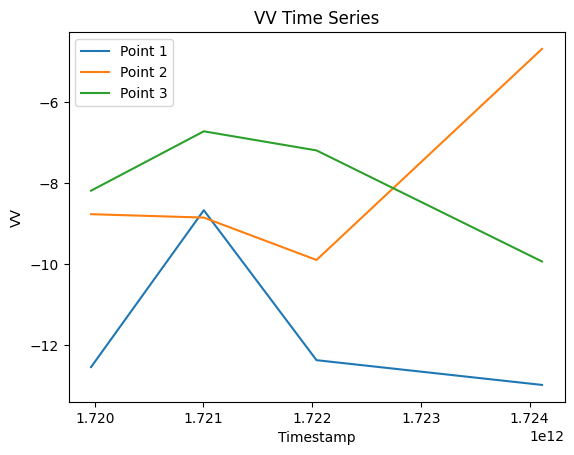

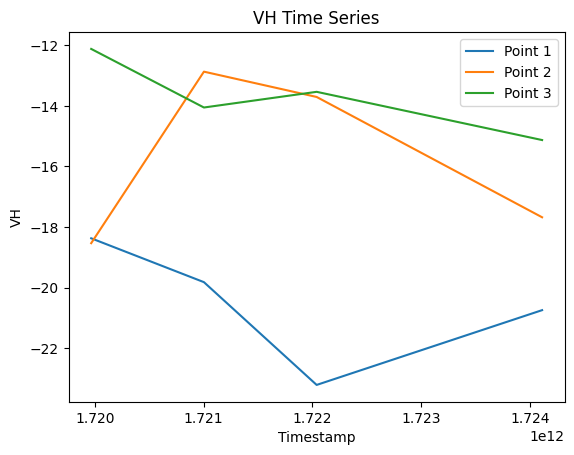

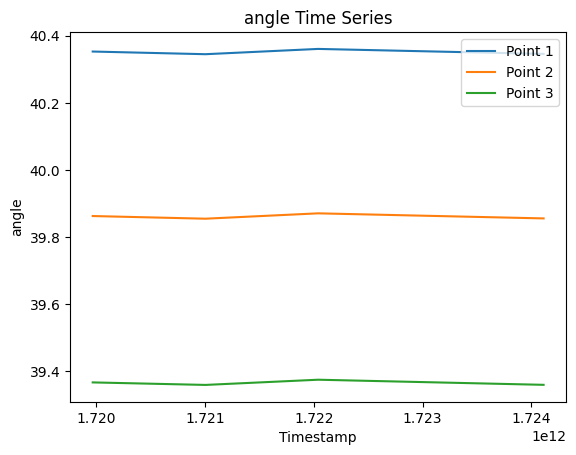

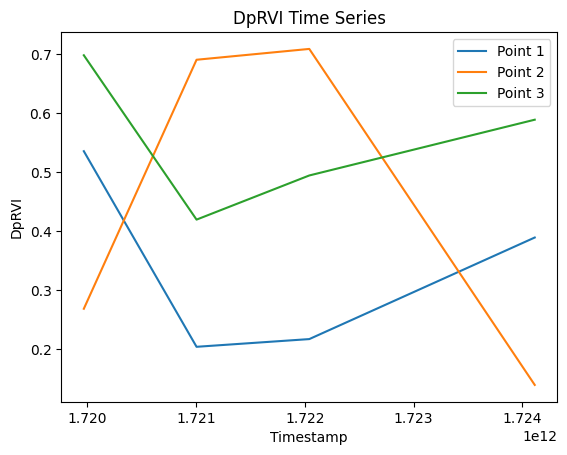

In [34]:
import matplotlib.pyplot as plt

bands_to_plot = ['VV', 'VH', 'angle', 'DpRVI']

for band in bands_to_plot:
    plt.figure()
    ax = plt.axes()
    for name, group in df_time_series_merged.groupby('name'):
        ax.plot(group['timestamp'], group[band], label=name)
    ax.set_title(f'{band} Time Series')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(band)
    ax.legend()
    plt.show()

## Export to csv

### Subtask:
Export the `df_time_series_merged` DataFrame to a CSV file.


**Reasoning**:
Export the merged DataFrame to a CSV file as requested in the subtask.



In [35]:
df_time_series_merged.to_csv('time_series_data_merged.csv', index=False)
print("DataFrame exported to time_series_data_merged.csv")

DataFrame exported to time_series_data_merged.csv


## Perform basic analysis

### Subtask:
Calculate and display basic statistics for the numerical columns in the `df_time_series_merged` DataFrame.


**Reasoning**:
Calculate and display descriptive statistics for the numerical columns in the df_time_series_merged DataFrame.



In [36]:
# Select only the numerical columns
numerical_cols = ['VH', 'VV', 'angle', 'DpRVI']
df_numerical = df_time_series_merged[numerical_cols]

# Calculate descriptive statistics
descriptive_stats = df_numerical.describe()

# Print the descriptive statistics
display(descriptive_stats)

,VH,VV,angle,DpRVI
count,12.000000,12.000000,12.000000,12.000000
mean,-16.648935,-9.228972,39.859309,0.445565
std,3.563770,2.498218,0.420376,0.205317
min,-23.214500,-12.976392,39.359688,0.138763
25%,-18.856114,-10.538959,39.373193,0.255017
50%,-16.404260,-8.804597,39.859373,0.456368
75%,-13.664187,-7.934384,40.345325,0.613710
max,-12.120396,-4.683967,40.360855,0.708282


from matplotlib import pyplot as plt
descriptive_stats['VH'].plot(kind='hist', bins=20, title='VH')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['VV'].plot(kind='hist', bins=20, title='VV')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['angle'].plot(kind='hist', bins=20, title='angle')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['DpRVI'].plot(kind='hist', bins=20, title='DpRVI')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
descriptive_stats.plot(kind='scatter', x='angle', y='DpRVI', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['VH'].plot(kind='line', figsize=(8, 4), title='VH')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['VV'].plot(kind='line', figsize=(8, 4), title='VV')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['angle'].plot(kind='line', figsize=(8, 4), title='angle')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
descriptive_stats['DpRVI'].plot(kind='line', figsize=(8, 4), title='DpRVI')
plt.gca().spines[['top', 'right']].set_visible(False)

## Summary:

### Data Analysis Key Findings
*   Line plots were successfully generated and displayed for the time series of VV, VH, angle, and DpRVI for each sample point, showing the change in values over time.
*   The `df_time_series_merged` DataFrame was successfully exported to a CSV file named `time_series_data_merged.csv`.
*   Descriptive statistics (count, mean, standard deviation, minimum, maximum, and quartile values) for the numerical columns ('VH', 'VV', 'angle', 'DpRVI') were calculated and displayed, providing insights into the data's distribution.

### Insights or Next Steps
*   The visualizations provide a good starting point for identifying temporal patterns or anomalies in the VV, VH, angle, and DpRVI values across different sample points.
*   The exported CSV file can be used for further analysis in other tools or for sharing the time series data.
